# R-Exec Demo

### Import Local Modules

In [1]:
from rexec.client_api import remote_func
from rexec.remote_obj import DSDataObj

import dxspaces
import numpy as np
import requests
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import time

### Configuration   

Adjust these parameters based on the setup and requirements.

In [2]:
# Remote execution broker addr
BROKER_ADDR = "ndp-dev-202.chpc.utah.edu"
BROKER_PORT = "30001"

# Optional API URL for rexec service
API_URL = "http://0.0.0.0:8000/rexec"

# Optional requirements file for remote environment setup
REQUIREMENTS_FILE = "input_requirements.txt"


# Optional DataSpaces server address
DSPACES_ADDR = None
# Disable dspace demo 
ENABLE_DATASPACES_DEMO = False

In [3]:
TOKEN = "<your_token>"

### Configure and spawn rexec server

In [4]:
# Configure remote execution using configuration parameters
remote_func().set_remote_addr(BROKER_ADDR)
remote_func().set_remote_port(BROKER_PORT)
print(f"Remote execution broker set to: {BROKER_ADDR}:{BROKER_PORT}")

# Set deployment API URL
remote_func().set_api_url(API_URL)
print(f"Deployment API URL set to: {API_URL}")

remote_func().set_environment(REQUIREMENTS_FILE, TOKEN)
print(f"Requirements file sent: {REQUIREMENTS_FILE}")

Remote execution broker set to: ndp-dev-202.chpc.utah.edu:30001
Deployment API URL set to: http://0.0.0.0:8000/rexec
Requirements file sent: input_requirements.txt


In [6]:
@remote_func
def foo(): return 1

print(foo)                # <rexec.client_api.remote_func object at ...>
print(foo.func)           # <function foo at ...>
print(foo.func())         # 1  (local execution bypassing remote layer)
print(foo())              # Remote execution path

<function foo at 0x1074fbce0>
1
1


### Define Simple Remote Function 

This section includes various remote functions demonstrating different capabilities of the remote execution framework.

In [7]:
# Simple remote functions for testing
@remote_func
def hello_world():
    return "hello world!"

@remote_func
def add(a, b):
    return a + b

@remote_func
def ds_add(dsa, dsb):
    """Add two DataSpaces objects"""
    return dsa + dsb

@remote_func
def ds_add3(dsa):
    """Complex DataSpaces operation"""
    return dsa * 2 + DSDataObj("arr1", 0, (0,0), (15, 15)) * 3

### Remote Execute

In [8]:
# Test simple remote functions

ret = hello_world()
print(f"hello_world(): {ret}")

ret = add(5, 2)
print(f"add(5, 2): {ret}")

ret = add(18, 100)
print(f"add(18, 100): {ret}")


# DataSpaces demo (only if enabled and configured)
if ENABLE_DATASPACES_DEMO and DSPACES_ADDR:
    print("\n=== Testing DataSpaces Integration ===")
    try:
        dspaces_client = dxspaces.DXSpacesClient(DSPACES_ADDR)
        print("Connected to DataSpaces API.")
        
        # Create and store test arrays
        arr1 = np.ones((16,16))
        dspaces_client.PutNDArray(arr1, "arr1", 0, (0,0))
        dspaces_client.PutNDArray(arr1, "arr2", 0, (0,0))
        print("Put arrays to DataSpaces... Done!")

        # Test DataSpaces operations
        var1 = DSDataObj("arr1", 0, (0,0), (15, 15))
        var2 = DSDataObj("arr2", 0, (0,0), (15, 15))

        ret = ds_add(var1, var2)
        print(f"ds_add result: {ret}")

        ret = ds_add3(var1)
        print(f"ds_add3 result: {ret}")
    except Exception as e:
        print(f"DataSpaces demo failed: {e}")
elif ENABLE_DATASPACES_DEMO:
    print("\n=== DataSpaces Demo Skipped ===")
    print("DSPACES_ADDR not configured. Set DSPACES_ADDR to enable DataSpaces demo.")

hello_world(): hello world!
add(5, 2): 7
add(18, 100): 118


In [9]:
print(add(12, 19))

31


In [9]:
@remote_func
def minus(a, b):
    return a - b

In [10]:
print(minus(10, 3))

7


# Advance Usage Demo: Remote execution and local execution compare
NOAA Geostationary Operational Environmental Satellites data processing

### Remote Function Definitions

In [14]:
@remote_func
def rfunc():
    import s3fs
    import numpy as np
    from netCDF4 import Dataset
    import matplotlib.pyplot as plt
    
    s3 = s3fs.S3FileSystem(anon=True)

    s3files = s3.ls("s3://noaa-goes17/ABI-L1b-RadC/2020/009/18/")
    s3file = None
    for f in s3files:
        if f.startswith("noaa-goes17/ABI-L1b-RadC/2020/009/18/OR_ABI-L1b-RadC-M6C03"):
            s3file = f
            break
    s3.get(f, "test.nc")
    data = Dataset("test.nc")
    array = data["Rad"]

    lb = (0, 2500)
    ub = (1499, 4999)
    index = [ slice(lb[x], ub[x]+1) for x in range(len(lb)) ]

    radiance = array[index]

    # Define some constants needed for the conversion. From the pdf linked above
    Esun_Ch_01 = 726.721072
    Esun_Ch_02 = 663.274497
    Esun_Ch_03 = 441.868715
    d2 = 0.3
    # Apply the formula to convert radiance to reflectance
    ref = (radiance * np.pi * d2) / Esun_Ch_02

    # Make sure all data is in the valid data range
    ref = np.maximum(ref, 0.0)
    ref = np.minimum(ref, 1.0)

    # Apply the formula to adjust reflectance gamma
    ref_gamma = np.sqrt(ref)

    fig, axs = plt.subplots()

    im = axs.imshow(ref_gamma, vmin=0.0, vmax=1.0, cmap='Greys_r')
    cb = plt.colorbar(im, orientation='horizontal')
    cb.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cb.set_label('Reflectance')
    plt.savefig("test.png")

    image = plt.imread("test.png")

    return image

### Local Function Definition

For comparison with remote execution, this is the same satellite data processing function running locally.

In [15]:
def lfunc():
    import s3fs
    import numpy as np
    from netCDF4 import Dataset
    import matplotlib.pyplot as plt
    
    s3 = s3fs.S3FileSystem(anon=True)

    s3files = s3.ls("s3://noaa-goes17/ABI-L1b-RadC/2020/009/18/")
    s3file = None
    for f in s3files:
        if f.startswith("noaa-goes17/ABI-L1b-RadC/2020/009/18/OR_ABI-L1b-RadC-M6C03"):
            s3file = f
            break
    s3.get(f, "test.nc")
    data = Dataset("test.nc")
    array = data["Rad"]

    lb = (0, 2500)
    ub = (1499, 4999)
    index = [ slice(lb[x], ub[x]+1) for x in range(len(lb)) ]

    radiance = array[index]

    # Define some constants needed for the conversion. From the pdf linked above
    Esun_Ch_01 = 726.721072
    Esun_Ch_02 = 663.274497
    Esun_Ch_03 = 441.868715
    d2 = 0.3
    # Apply the formula to convert radiance to reflectance
    ref = (radiance * np.pi * d2) / Esun_Ch_02

    # Make sure all data is in the valid data range
    ref = np.maximum(ref, 0.0)
    ref = np.minimum(ref, 1.0)

    # Apply the formula to adjust reflectance gamma
    ref_gamma = np.sqrt(ref)

    fig, axs = plt.subplots()

    im = axs.imshow(ref_gamma, vmin=0.0, vmax=1.0, cmap='Greys_r')
    cb = plt.colorbar(im, orientation='horizontal')
    cb.set_ticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    cb.set_label('Reflectance')
    plt.savefig("test.png")

    image = plt.imread("test.png")

    cb.remove()

    return image

### Demo Execution

This section demonstrates the setup and execution of complex remote function of NASA satellite data processing.

Remote Exec time is 1.638766041956842 second.


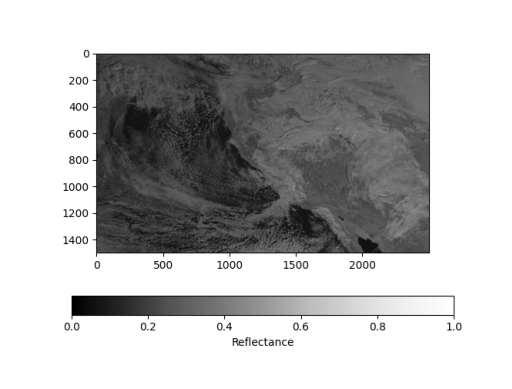

Local Exec time is 2.7846982500050217 second.


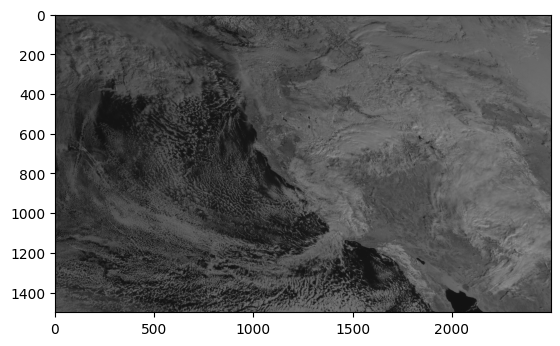

In [18]:
start = time.perf_counter()
image = rfunc()
end = time.perf_counter()
print(f"Remote Exec time is {end-start} second.")

plt.imshow(image)
plt.axis('off')
plt.show()

start = time.perf_counter()
limage = lfunc()
end = time.perf_counter()
print(f"Local Exec time is {end-start} second.")